In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
countries = pd.read_csv(
    "../../../data/processed/airports/countries/countries_processed.csv"
)

In [3]:
countries.head()

,id,code,name,continent
0,302672,AD,Andorra,EU
1,302618,AE,United Arab Emirates,AS
2,302619,AF,Afghanistan,AS
3,302722,AG,Antigua and Barbuda,NaN
4,302723,AI,Anguilla,NaN


In [4]:
countries.shape

(249, 4)

In [5]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         249 non-null    int64 
 1   code       248 non-null    object
 2   name       249 non-null    object
 3   continent  208 non-null    object
dtypes: int64(1), object(3)
memory usage: 7.9+ KB


In [6]:
continent = countries["continent"].value_counts(dropna=False)

continent

continent
AF     60
AS     55
EU     50
NaN    41
OC     27
SA     14
AN      2
Name: count, dtype: int64

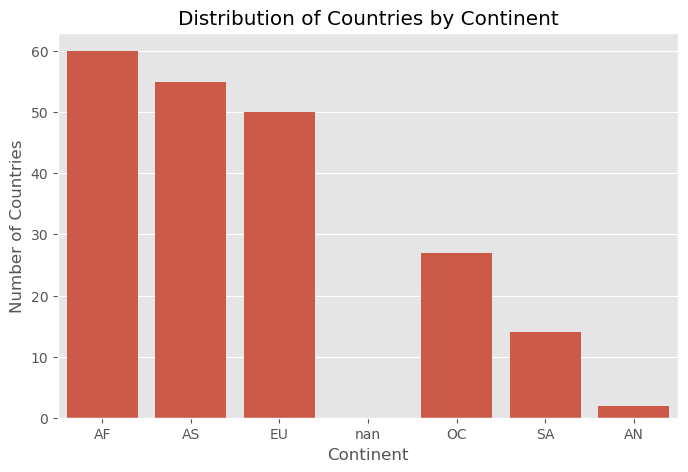

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="continent",
    data=countries,
    order=continent.index
)

plt.title("Distribution of Countries by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of Countries")

plt.show()

In [8]:
countries[
    countries["continent"].isnull()
]

,id,code,name,continent
3,302722,AG,Antigua and Barbuda,NaN
4,302723,AI,Anguilla,NaN
13,302725,AW,Aruba,NaN
16,302726,BB,Barbados,NaN
24,302760,BL,Saint Barthélemy,NaN
25,302727,BM,Bermuda,NaN
28,302724,BQ,Caribbean Netherlands,NaN
30,302728,BS,Bahamas,NaN
34,302729,BZ,Belize,NaN
35,302730,CA,Canada,NaN


In [9]:
countries["name_length"] = countries["name"].str.len()

In [10]:
countries["name_length"].describe()

count    249.000000
mean      10.184739
std        6.795843
min        4.000000
25%        6.000000
50%        8.000000
75%       11.000000
max       44.000000
Name: name_length, dtype: float64

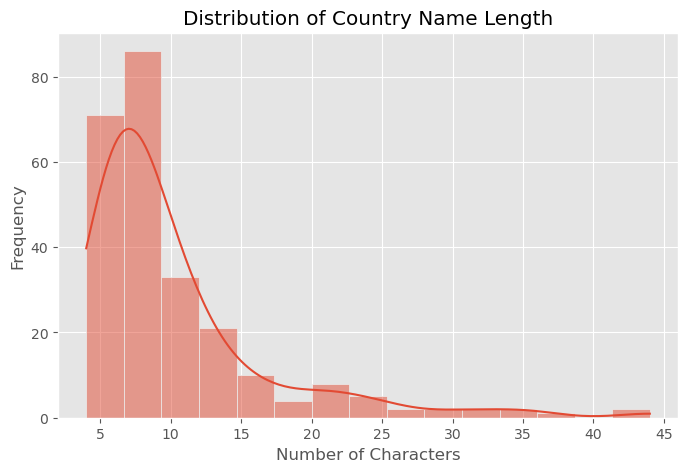

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    countries["name_length"],
    bins=15,
    kde=True
)

plt.title("Distribution of Country Name Length")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

In [12]:
countries.nlargest(
    10,
    "name_length"
)[["name","name_length"]]

,name,name_length
87,South Georgia and the South Sandwich Islands,44
196,"Saint Helena, Ascension and Tristan da Cunha",44
228,United States Minor Outlying Islands,36
63,Western Sahara (disputed territory),35
212,French Southern and Antarctic Lands,35
37,Democratic Republic of the Congo,32
233,Saint Vincent and the Grenadines,32
103,British Indian Ocean Territory,30
248,Unknown or unassigned country,29
93,Heard and McDonald Islands,26


## Exploratory Data Analysis Summary

The exploratory analysis shows that the countries dataset provides comprehensive global coverage through standardized country identifiers and continent classifications. The dataset contains minimal missing values and no significant data quality issues affecting integration. Since the dataset functions primarily as a reference table, the analysis focuses on validating geographic coverage and completeness rather than complex statistical relationships. The cleaned dataset is suitable for enriching airport records during the Airport Module integration stage.